In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polatory as p
import polatory.two as p2

def variog(m: p2.Model, diff: np.ndarray) -> float:
    v = m.nugget
    for rbf in m.rbfs:
        v += rbf.evaluate(np.zeros(2)) - rbf.evaluate(diff)
    return v

In [2]:
data = pd.read_csv("data/sim2d.csv")
points = data[["x", "y"]].values
values = data["sim1"].values
data.describe()

,x,y,sim1
count,50000.000000,50000.000000,50000.000000
mean,499.016406,498.513760,-0.041821
std,289.666773,289.102680,1.479260
min,0.007518,0.032921,-5.325610
25%,246.990108,247.810071,-1.057064
50%,498.765533,497.691144,-0.030151
75%,751.926022,748.983995,0.972460
max,999.974991,999.977219,5.339560


In [3]:
calc = p2.VariogramCalculator(lag_distance=5.0, num_lags=200)
calc.directions = p2.DIRECTIONS_8
variogs = calc.calculate(points, values)

In [4]:
cov1 = p2.CovSpherical([1.0, 50.0])
cov2 = p2.CovSpherical([1.0, 100.0])
covs = [cov1, cov2]
m = p2.Model(covs, poly_degree=-1)

best_fit = None
best_cost = float("inf")
for _ in range(10):
    fit = p2.VariogramFitting(variogs, m)
    if fit.final_cost < best_cost:
        best_fit = fit
        best_cost = fit.final_cost

m = best_fit.model
print(m.description)

        Type       Psill       Major       Minor    Rotation
         nug      0.1006
         sph      1.3741     58.4121     30.2338    163.2636
         sph      0.7181    174.3190     62.7190    163.2636



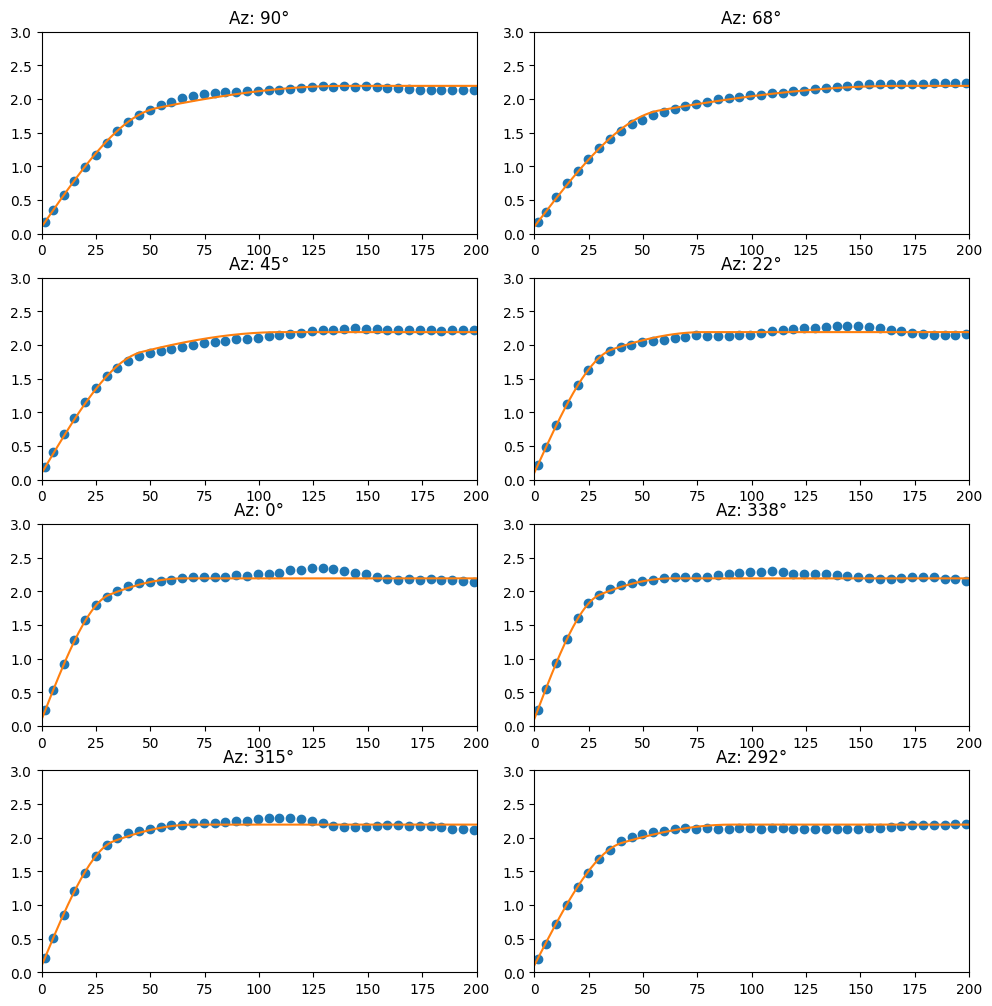

In [5]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(10, 10))
fig.tight_layout()
for i in range(4):
    for j in range(2):
        if 2 * i + j >= len(variogs):
            break
        v = variogs[2 * i + j]
        dir = v.direction
        az = np.degrees(np.arctan2(dir[0], dir[1]))
        if az < 0.0:
            az += 360.0
        xs = np.linspace(0.0, 1000.0, 1000)
        ys = np.array([variog(m, x * dir) for x in xs])
        ax[i, j].plot(np.linalg.norm(v.bin_lag, axis=1), v.bin_gamma, "o")
        ax[i, j].plot(xs, ys, "-")
        ax[i, j].set_title(f"Az: {az:.0f}°")
        ax[i, j].set_xlim(0.0, 200.0)
        ax[i, j].set_ylim(0.0, 3)
        ax[i, j].margins(0.0)